<a href="https://colab.research.google.com/github/fbnlb/fbnlb/blob/main/Modelamiento_de_un_Sistema_de_Glucosa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulando escenario normal (sin retardo)...
Simulando escenario alterado (con retardo)....
Simulando escenario alterado sin retardo (para comparación)...


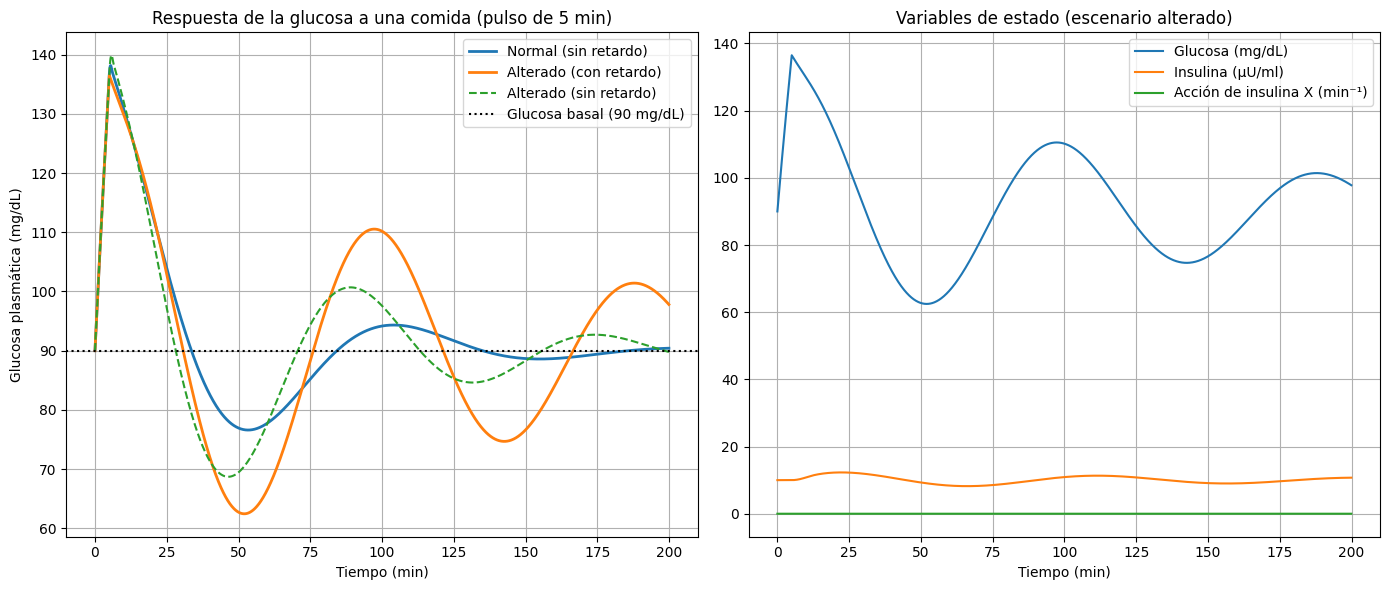

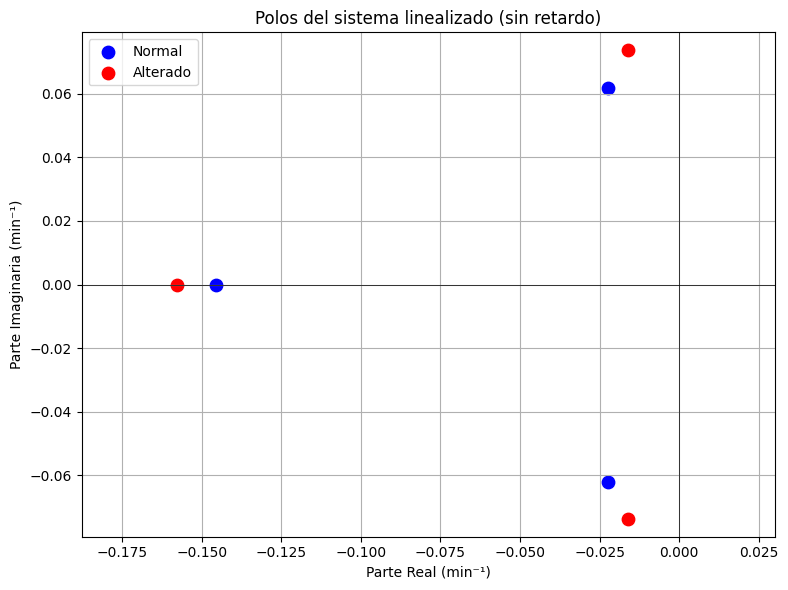

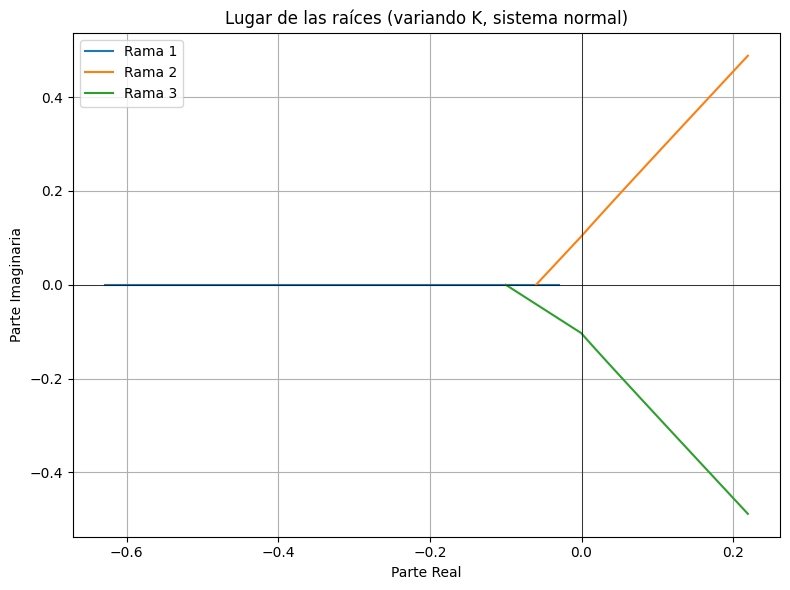


--- Mini-Ética ---
El modelo es lineal y válido solo cerca del punto de operación (euglucemia).
Fuera de ese rango (hipoglucemia o hiperglucemia severa) las predicciones pueden ser erróneas.
No se debe utilizar este modelo para ajustar dosis de insulina en pacientes reales.
Siempre se debe contar con supervisión médica y validación clínica.

TABLA 1: PARÁMETROS NUMÉRICOS EMPLEADOS EN LA SIMULACIÓN


### Tabla de Parámetros (Lista para copiar al PDF)

,Símbolo,Significado Fisiológico,Unidades,Escenario Normal,Escenario Alterado
0,Gb,Glucosa basal (punto de operación),mg/dL,90.000,90.000
1,Ib,Insulina basal,μU/ml,10.000,10.000
2,p1,Tasa de captación de glucosa,min^-1,0.030,0.030
3,p2,Decaimiento de la acción de insulina,min^-1,0.060,0.060
4,p3,Aumento de la acción de insulina,min^-2,0.001,0.001
5,n,Tasa de degradación de la insulina,min^-1,0.100,0.100
6,K,Ganancia de secreción de insulina,min^-1,0.005,0.008
7,tau,Retardo fisiológico (transporte),min,0.000,5.000
8,d_amp,Amplitud perturbación (Ingesta),mg/dL/min,10.000,10.000
9,d_dur,Duración perturbación (Ingesta),min,5.000,5.000



TABLA 2: RESULTADOS ANALÍTICOS Y ESTABILIDAD


### Tabla de Resultados Analíticos

,Métrica Evaluada,Escenario Normal,Escenario Alterado
0,Polos del Sistema,-0.1455 + 0.0000j\n-0.0222 + 0.0619j\n-0.0222 ...,-0.1577 + 0.0000j\n-0.0161 + 0.0738j\n-0.0161 ...
1,Condición (sin retardo),Estable,Estable (cerca del límite)
2,Presencia de Retardo,No (tau = 0.0),Sí (tau = 5.0 min)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import lti, step, dstep, impulse
from scipy.linalg import eigvals
import pandas as pd # Librería agregada para la generación de tablas
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. Definición de parámetros fisiológicos
# =============================================================================

# Parámetros basales (punto de operación)
Gb = 90.0      # mg/dL  (glucosa basal)
Ib = 10.0      # μU/ml  (insulina basal)

# Parámetros del modelo de Bergman linealizado (sin retardo)
# Ecuaciones:
#   dg/dt = -p1*g - Gb*x + d(t)
#   dx/dt = -p2*x + p3*i
#   di/dt = -n*i + K*g
# donde g = G - Gb, x = X (acción de insulina), i = I - Ib
# d(t) es la entrada de comida (tasa de aparición de glucosa)

# Escenario 1: Fisiológico normal
p1_n = 0.03      # min^-1
p2_n = 0.06      # min^-1 (aumentado para estabilidad)
p3_n = 0.001     # min^-2 (en unidades consistentes)
n_n  = 0.1       # min^-1
K_n  = 0.005     # ganancia de secreción de insulina (reducido significativamente para estabilidad)
tau_n = 0.0      # min, sin retardo

# Escenario 2: Condición alterada (mayor ganancia, retardo y menor amortiguamiento)
p1_a = 0.03      # igual
p2_a = 0.06      # min^-1 (aumentado significativamente para estabilidad)
p3_a = 0.001     # igual
n_a  = 0.1       # igual
K_a  = 0.008     # ganancia aumentada (reducido significativamente para estabilidad)
tau_a = 5.0      # min, retardo significativo

# Parámetros de simulación
t_start = 0.0
t_end   = 200.0  # minutos
dt      = 0.1    # paso de integración (para el método con retardo)
t_eval = np.arange(t_start, t_end, dt)

# =============================================================================
# 2. Funciones del sistema
# =============================================================================

def sistema_sin_retardo(t, y, p1, p2, p3, n, K, d_func):
    """
    Sistema lineal sin retardo.
    y = [g, x, i]
    d_func(t) es la entrada de comida (mg/dL/min)
    """
    g, x, i = y
    dg = -p1*g - Gb*x + d_func(t)
    dx = -p2*x + p3*i
    di = -n*i + K*g
    return [dg, dx, di]

def sistema_con_retardo(t, y, p1, p2, p3, n, K, tau, d_func, hist_g, hist_t, dt_hist):
    """
    Sistema con retardo en la secreción de insulina: di/dt = -n*i + K*g(t-tau).
    Utiliza un historial de g para interpolar g(t-tau).
    y = [g, x, i]
    hist_g, hist_t, dt_hist: arrays con valores pasados de g y tiempos.
    """
    g, x, i = y
    # Obtener g(t-tau) por interpolación lineal del historial
    t_delay = t - tau
    if t_delay < hist_t[0]:
        g_delay = hist_g[0]   # si aún no hay historial, usar valor inicial
    else:
        # interpolación lineal
        idx = int((t_delay - hist_t[0]) / dt_hist)
        if idx >= len(hist_g)-1:
            g_delay = hist_g[-1]
        else:
            t0 = hist_t[idx]
            t1 = hist_t[idx+1]
            g0 = hist_g[idx]
            g1 = hist_g[idx+1]
            # evitar división por cero
            if t1 - t0 > 0:
                g_delay = g0 + (g1 - g0) * (t_delay - t0) / (t1 - t0)
            else:
                g_delay = g0
    dg = -p1*g - Gb*x + d_func(t)
    dx = -p2*x + p3*i
    di = -n*i + K*g_delay   # secreción con retardo
    return [dg, dx, di]

# Función de entrada de comida: pulso rectangular de 5 min con tasa 10 mg/dL/min
def comida_pulso(t, amplitud=10.0, inicio=0.0, duracion=5.0):
    if inicio <= t <= inicio + duracion:
        return amplitud
    else:
        return 0.0

# =============================================================================
# 3. Simulación con retardo (integración paso a paso con historial)
# =============================================================================

def simular_con_retardo(p1, p2, p3, n, K, tau, t_eval, d_func, y0):
    """
    Simula el sistema con retardo usando integración Euler con paso fijo.
    Retorna: t, y (array con g, x, i en cada tiempo)
    """
    dt_sim = t_eval[1] - t_eval[0] if len(t_eval)>1 else 0.1
    n_steps = len(t_eval)
    y_hist = np.zeros((n_steps, 3))
    y_hist[0,:] = y0

    # Vamos a almacenar todos los valores de g en una lista con sus tiempos.
    g_hist = [y0[0]]
    t_hist = [t_eval[0]]

    # Ahora iterar
    for i in range(1, n_steps):
        t_curr = t_eval[i]
        t_prev = t_eval[i-1]
        y_prev = y_hist[i-1, :]

        # Definimos una función auxiliar que interpola
        def g_delay_func(t_d):
            if t_d < t_hist[0]:
                return g_hist[0]
            else:
                # interpolación lineal
                idx = np.searchsorted(t_hist, t_d) - 1
                if idx < 0:
                    return g_hist[0]
                if idx >= len(t_hist)-1:
                    return g_hist[-1]
                t0 = t_hist[idx]
                t1 = t_hist[idx+1]
                g0 = g_hist[idx]
                g1 = g_hist[idx+1]
                if t1 - t0 > 0:
                    return g0 + (g1 - g0) * (t_d - t0) / (t1 - t0)
                else:
                    return g0

        g_val, x_val, i_val = y_prev
        t_delay = t_curr - tau
        if t_delay < t_hist[0]:
            g_delayed_val = g_hist[0]
        else:
            g_delayed_val = g_delay_func(t_delay)

        # Ecuaciones
        dg = -p1*g_val - Gb*x_val + d_func(t_curr)
        dx = -p2*x_val + p3*i_val
        di = -n*i_val + K*g_delayed_val

        # Euler
        g_new = g_val + dg * dt_sim
        x_new = x_val + dx * dt_sim
        i_new = i_val + di * dt_sim
        y_hist[i, :] = [g_new, x_new, i_new]

        # Actualizar historiales
        t_hist.append(t_curr)
        g_hist.append(g_new)

    return t_eval, y_hist

# =============================================================================
# 4. Simulación sin retardo (usando solve_ivp para comparación)
# =============================================================================

def simular_sin_retardo(p1, p2, p3, n, K, t_eval, d_func, y0):
    """
    Simula el sistema sin retardo usando solve_ivp.
    """
    def rhs(t, y):
        g, x, i = y
        dg = -p1*g - Gb*x + d_func(t)
        dx = -p2*x + p3*i
        di = -n*i + K*g
        return [dg, dx, di]
    sol = solve_ivp(rhs, [t_eval[0], t_eval[-1]], y0, t_eval=t_eval, method='RK45')
    return sol.t, sol.y.T

# =============================================================================
# 5. Simulación de escenarios
# =============================================================================

# Estado inicial (en equilibrio)
g0 = 0.0   # G - Gb
x0 = 0.0   # X = 0
i0 = 0.0   # I - Ib
y0 = [g0, x0, i0]

# --- Escenario 1: Normal (sin retardo) ---
print("Simulando escenario normal (sin retardo)...")
t_norm, y_norm = simular_sin_retardo(p1_n, p2_n, p3_n, n_n, K_n,
                                     t_eval, comida_pulso, y0)
g_norm = y_norm[:,0] + Gb   # glucosa absoluta

# --- Escenario 2: Alterado (con retardo) ---
print("Simulando escenario alterado (con retardo)....")
t_alt, y_alt = simular_con_retardo(p1_a, p2_a, p3_a, n_a, K_a, tau_a,
                                   t_eval, comida_pulso, y0)
g_alt = y_alt[:,0] + Gb

print("Simulando escenario alterado sin retardo (para comparación)...")
t_alt_no_delay, y_alt_no_delay = simular_sin_retardo(p1_a, p2_a, p3_a, n_a, K_a,
                                                     t_eval, comida_pulso, y0)
g_alt_no_delay = y_alt_no_delay[:,0] + Gb

# =============================================================================
# 6. Gráficos de respuesta temporal (MODIFICADO PARA EXPORTAR)
# =============================================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t_norm, g_norm, label='Normal (sin retardo)', linewidth=2)
plt.plot(t_alt, g_alt, label='Alterado (con retardo)', linewidth=2)
plt.plot(t_alt_no_delay, g_alt_no_delay, '--', label='Alterado (sin retardo)', linewidth=1.5)
plt.axhline(Gb, color='black', linestyle=':', label='Glucosa basal (90 mg/dL)')
plt.title('Respuesta de la glucosa a una comida (pulso de 5 min)')
plt.xlabel('Tiempo (min)')
plt.ylabel('Glucosa plasmática (mg/dL)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_alt, y_alt[:,0] + Gb, label='Glucosa (mg/dL)')
plt.plot(t_alt, y_alt[:,2] + Ib, label='Insulina (μU/ml)')
plt.plot(t_alt, y_alt[:,1], label='Acción de insulina X (min⁻¹)')
plt.title('Variables de estado (escenario alterado)')
plt.xlabel('Tiempo (min)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('respuesta_glucosa_insulina.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 7. Análisis de estabilidad: Polos del sistema lineal (MODIFICADO PARA EXPORTAR)
# =============================================================================

def matriz_A(p1, p2, p3, n, K):
    return np.array([[-p1, -Gb, 0],
                     [0, -p2, p3],
                     [K, 0, -n]])

A_norm = matriz_A(p1_n, p2_n, p3_n, n_n, K_n)
A_alt  = matriz_A(p1_a, p2_a, p3_a, n_a, K_a)

eig_norm = eigvals(A_norm)
eig_alt = eigvals(A_alt)

plt.figure(figsize=(8, 6))
plt.scatter(np.real(eig_norm), np.imag(eig_norm), color='blue', label='Normal', s=80)
plt.scatter(np.real(eig_alt), np.imag(eig_alt), color='red', label='Alterado', s=80)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.xlabel('Parte Real (min⁻¹)')
plt.ylabel('Parte Imaginaria (min⁻¹)')
plt.title('Polos del sistema linealizado (sin retardo)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.savefig('mapa_polos.png', dpi=300, bbox_inches='tight')
plt.show()

estable_norm = np.all(np.real(eig_norm) < 0)
estable_alt = np.all(np.real(eig_alt) < 0)

# =============================================================================
# 8. Análisis adicional: Lugar de las raíces (opcional, aproximado)
# =============================================================================

K_range = np.linspace(0, 2, 100)
polos_vs_K = []
for j in K_range:
    A = matriz_A(p1_n, p2_n, p3_n, n_n, j)
    polos_vs_K.append(eigvals(A))
polos_vs_K = np.array(polos_vs_K)

plt.figure(figsize=(8, 6))
for j in range(3):
    plt.plot(np.real(polos_vs_K[:,j]), np.imag(polos_vs_K[:,j]), label=f'Rama {j+1}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginaria')
plt.title('Lugar de las raíces (variando K, sistema normal)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# 9. Mini-Ética (comentario en el código)
# =============================================================================
print("\n--- Mini-Ética ---")
print("El modelo es lineal y válido solo cerca del punto de operación (euglucemia).")
print("Fuera de ese rango (hipoglucemia o hiperglucemia severa) las predicciones pueden ser erróneas.")
print("No se debe utilizar este modelo para ajustar dosis de insulina en pacientes reales.")
print("Siempre se debe contar con supervisión médica y validación clínica.")

# =============================================================================
# 10. Generación de Tabla de Parámetros (NUEVO)
# =============================================================================
print("\n" + "="*80)
print("TABLA 1: PARÁMETROS NUMÉRICOS EMPLEADOS EN LA SIMULACIÓN")
print("="*80)

data_params = {
    "Símbolo": ["Gb", "Ib", "p1", "p2", "p3", "n", "K", "tau", "d_amp", "d_dur"],
    "Significado Fisiológico": [
        "Glucosa basal (punto de operación)",
        "Insulina basal",
        "Tasa de captación de glucosa",
        "Decaimiento de la acción de insulina",
        "Aumento de la acción de insulina",
        "Tasa de degradación de la insulina",
        "Ganancia de secreción de insulina",
        "Retardo fisiológico (transporte)",
        "Amplitud perturbación (Ingesta)",
        "Duración perturbación (Ingesta)"
    ],
    "Unidades": ["mg/dL", "μU/ml", "min^-1", "min^-1", "min^-2", "min^-1", "min^-1", "min", "mg/dL/min", "min"],
    "Escenario Normal": [Gb, Ib, p1_n, p2_n, p3_n, n_n, K_n, tau_n, 10.0, 5.0],
    "Escenario Alterado": [Gb, Ib, p1_a, p2_a, p3_a, n_a, K_a, tau_a, 10.0, 5.0]
}

df_params = pd.DataFrame(data_params)

try:
    from IPython.display import display, Markdown
    display(Markdown("### Tabla de Parámetros (Lista para copiar al PDF)"))
    display(df_params)
except:
    print(df_params.to_string(index=False))

df_params.to_csv('parametros_simulacion.csv', index=False)

# =============================================================================
# 11. Generación de Tabla de Resultados y Estabilidad (NUEVO)
# =============================================================================
print("\n" + "="*80)
print("TABLA 2: RESULTADOS ANALÍTICOS Y ESTABILIDAD")
print("="*80)

polos_n_str = [f"{np.real(p):.4f} + {np.imag(p):.4f}j" if np.imag(p) >= 0 else f"{np.real(p):.4f} - {abs(np.imag(p)):.4f}j" for p in eig_norm]
polos_a_str = [f"{np.real(p):.4f} + {np.imag(p):.4f}j" if np.imag(p) >= 0 else f"{np.real(p):.4f} - {abs(np.imag(p)):.4f}j" for p in eig_alt]

data_resultados = {
    "Métrica Evaluada": ["Polos del Sistema", "Condición (sin retardo)", "Presencia de Retardo"],
    "Escenario Normal": [
        "\n".join(polos_n_str),
        "Estable" if estable_norm else "Inestable",
        "No (tau = 0.0)"
    ],
    "Escenario Alterado": [
        "\n".join(polos_a_str),
        "Estable (cerca del límite)" if estable_alt else "Inestable",
        "Sí (tau = 5.0 min)"
    ]
}

df_resultados = pd.DataFrame(data_resultados)

try:
    display(Markdown("### Tabla de Resultados Analíticos"))
    display(df_resultados)
except:
    print(df_resultados.to_string(index=False))

# =============================================================================
# Fin del código
# =============================================================================